In [1]:
import pandas  as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, \
recall_score, f1_score, confusion_matrix


df = pd.read_csv('train.csv')
df


C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.0)
  from scipy.sparse import csr_matrix, issparse


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [2]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.')
df['HasCabin'] = df['Cabin'].notnull().astype(int)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.')

title_map = {
'Mr':1,
'Miss':2,
'Mrs':3,
'Master':4
}
df['Title_mapped'] = df['Title'].map(title_map).fillna(0)
df['FarePerPerson'] = df['Fare'] / df['FamilySize']
df['AgeGroup'] = (df['Age'] // 10) * 10
df['CabinDeck'] = df['Cabin'].str[0]
deck_map = {
'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7
}

df['CabinDeck'] = df['CabinDeck'].map(deck_map).fillna(0)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    891 non-null    int64  
 1   Survived       891 non-null    int64  
 2   Pclass         891 non-null    int64  
 3   Name           891 non-null    object 
 4   Sex            891 non-null    object 
 5   Age            891 non-null    float64
 6   SibSp          891 non-null    int64  
 7   Parch          891 non-null    int64  
 8   Ticket         891 non-null    object 
 9   Fare           891 non-null    float64
 10  Cabin          204 non-null    object 
 11  Embarked       889 non-null    object 
 12  FamilySize     891 non-null    int64  
 13  IsAlone        891 non-null    int64  
 14  Title          891 non-null    object 
 15  HasCabin       891 non-null    int64  
 16  Title_mapped   891 non-null    float64
 17  FarePerPerson  891 non-null    float64
 18  AgeGroup  

In [3]:
X = df[['Age','Fare','FamilySize','Pclass','IsAlone', 'HasCabin','Title_mapped','FarePerPerson','AgeGroup','CabinDeck']]
y = df['Survived']

In [4]:
X.shape

(891, 10)

In [5]:
X_train, X_test, y_train, y_test = train_test_split( X , y , test_size=0.1, random_state=42)

In [6]:
X_train

,Age,Fare,FamilySize,Pclass,IsAlone,HasCabin,Title_mapped,FarePerPerson,AgeGroup,CabinDeck
165,9.0,20.5250,3,3,0,0,4.0,6.841667,0.0,0.0
541,9.0,31.2750,7,3,0,0,2.0,4.467857,0.0,0.0
625,61.0,32.3208,1,1,1,1,1.0,32.320800,60.0,4.0
388,28.0,7.7292,1,3,1,0,1.0,7.729200,20.0,0.0
76,28.0,7.8958,1,3,1,0,1.0,7.895800,20.0,0.0
...,...,...,...,...,...,...,...,...,...,...
106,21.0,7.6500,1,3,1,0,2.0,7.650000,20.0,0.0
270,28.0,31.0000,1,1,1,0,1.0,31.000000,20.0,0.0
860,41.0,14.1083,3,3,0,0,1.0,4.702767,40.0,0.0
435,14.0,120.0000,4,1,0,1,2.0,30.000000,10.0,2.0


In [7]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90 entries, 709 to 250
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            90 non-null     float64
 1   Fare           90 non-null     float64
 2   FamilySize     90 non-null     int64  
 3   Pclass         90 non-null     int64  
 4   IsAlone        90 non-null     int64  
 5   HasCabin       90 non-null     int64  
 6   Title_mapped   90 non-null     float64
 7   FarePerPerson  90 non-null     float64
 8   AgeGroup       90 non-null     float64
 9   CabinDeck      90 non-null     float64
dtypes: float64(6), int64(4)
memory usage: 7.7 KB


In [8]:
y_train

165    1
541    0
625    0
388    0
76     0
      ..
106    1
270    0
860    0
435    1
102    0
Name: Survived, Length: 801, dtype: int64

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
model = DecisionTreeClassifier(max_depth=6, random_state=42)
model.fit( X_train_scaled , y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [11]:
model2 = RandomForestClassifier(n_estimators=300, max_depth=7,  random_state=42)
model2.fit( X_train_scaled , y_train)

RandomForestClassifier(max_depth=7, n_estimators=300, random_state=42)

In [12]:
y_pred = model.predict(X_test_scaled)
y_pred2 = model2.predict(X_test_scaled)


In [13]:
y_pred
y_pred2

array([1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0])

In [14]:
accuracy = accuracy_score( y_test, y_pred)

In [15]:
print(f'모델 정확도 : {accuracy:.2f}')

모델 정확도 : 0.88


In [16]:
print(f'정확도(Accuracy): {accuracy_score( y_test, y_pred):.2f}')
print(f'정밀도(precision): {precision_score( y_test, y_pred):.2f}')
print(f'재현율(recall): {recall_score( y_test, y_pred):.2f}')
print(f'f1점수(f1 score): {f1_score( y_test, y_pred):.2f}')

정확도(Accuracy): 0.88
정밀도(precision): 0.80
재현율(recall): 0.92
f1점수(f1 score): 0.86


In [17]:
print(f'정확도(Accuracy): {accuracy_score( y_test, y_pred2):.2f}')
print(f'정밀도(precision): {precision_score( y_test, y_pred2):.2f}')
print(f'재현율(recall): {recall_score( y_test, y_pred2):.2f}')
print(f'f1점수(f1 score): {f1_score( y_test, y_pred2):.2f}')

정확도(Accuracy): 0.86
정밀도(precision): 0.79
재현율(recall): 0.86
f1점수(f1 score): 0.83


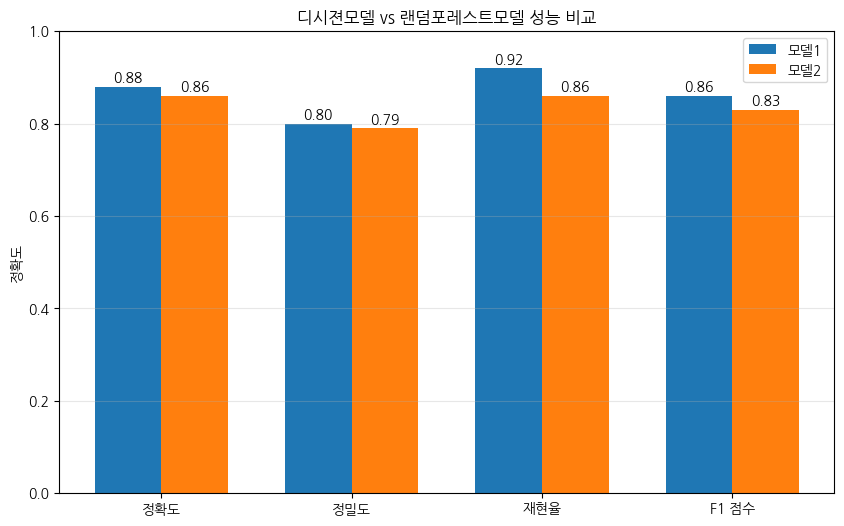

In [20]:
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np

# 모델 성능 데이터
metrics = ['정확도', '정밀도', '재현율', 'F1 점수']
model1 = [0.88, 0.80, 0.92, 0.86]
model2 = [0.86, 0.79, 0.86, 0.83]

x = np.arange(len(metrics))   # x축 위치
width = 0.35                  # 막대 너비

plt.figure(figsize=(10,6))

# 막대 그래프
bars1 = plt.bar(x - width/2, model1, width, label='모델1')
bars2 = plt.bar(x + width/2, model2, width, label='모델2')

# 제목과 축
plt.title('디시젼모델 vs 랜덤포레스트모델 성능 비교')
plt.xticks(x, metrics)
plt.ylabel('정확도')
plt.ylim(0, 1.0)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# 막대 위에 숫자 표시
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f'{height:.2f}', ha='center', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f'{height:.2f}', ha='center', fontsize=10)

plt.show()